In [ ]:
#checking for GPU
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!ls

sample_data


In [ ]:
!pip install -q kaggle

In [ ]:
import json

kaggle_data = {
    "username": "Kaggle",
    "key": "KGAT_94badf1021e997ffa82a3299b41bd531"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_data, f)

print("kaggle.json file created!")

kaggle.json file created!


In [ ]:

!pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:




!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_279.jpg  
  inflating: Training/glioma/Tr-gl_28.jpg  
  inflating: Training/glioma/Tr-gl_280.jpg  
  inflating: Training/glioma/Tr-gl_281.jpg  
  inflating: Training/glioma/Tr-gl_282.jpg  
  inflating: Training/glioma/Tr-gl_283.jpg  
  inflating: Training/glioma/Tr-gl_284.jpg  
  inflating: Training/glioma/Tr-gl_285.jpg  
  inflating: Training/glioma/Tr-gl_286.jpg  
  inflating: Training/glioma/Tr-gl_287.jpg  
  inflating: Training/glioma/Tr-gl_288.jpg  
  inflating: Training/glioma/Tr-gl_289.jpg  
  inflating: Training/glioma/Tr-gl_29.jpg  
  inflating: Training/glioma/Tr-gl_290.jpg  
  inflating: Training/glioma/Tr-gl_291.jpg  
  inflating: Training/glioma/Tr-gl_292.jpg  
  inflating: Training/glioma/Tr-gl_293.jpg  
  inflating: Training/glioma/Tr-gl_294.jpg  
  inflating: Training/glioma/Tr-gl_295.jpg  
  inflating: Training/glioma/Tr-gl_296.jpg  
  inflating: Training/glioma/Tr-gl_297.jpg  
  infl

In [ ]:
!ls

brain-tumor-mri-dataset.zip  kaggle.json  sample_data  Testing	Training


In [ ]:
## connecting data set properly
train_path = "/content/Training"
test_path = "/content/Testing"

import os
print("Classes:", os.listdir(train_path))

Classes: ['pituitary', 'meningioma', 'glioma', 'notumor']


In [ ]:
# create data generator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 5600 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.


In [ ]:
## Build MobileVetNetV2 Model - it is Pretrained CNN model
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,263,108 (8.63 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
## TRAIN THE MODEL
history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 96s 445ms/step - accuracy: 0.6829 - loss: 0.7959 - val_accuracy: 0.7675 - val_loss: 0.6969
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 76s 432ms/step - accuracy: 0.8048 - loss: 0.4978 - val_accuracy: 0.7862 - val_loss: 0.7132
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 77s 400ms/step - accuracy: 0.8380 - loss: 0.4302 - val_accuracy: 0.7894 - val_loss: 0.7056
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 401ms/step - accuracy: 0.8539 - loss: 0.3932 - val_accuracy: 0.8019 - val_loss: 0.6717
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 402ms/step - accuracy: 0.8537 - loss: 0.3867 - val_accuracy: 0.7763 - val_loss: 0.7210
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 402ms/step - accuracy: 0.8616 - loss: 0.3727 - val_accuracy: 0.8194 - val_loss: 0.6241
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 70s 402ms/step - accuracy: 0.8579 - loss: 0.3717 - val_accuracy: 0.7962 - val_loss: 0.6741
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 71s 405ms/step - accuracy: 0.8632 - loss: 0

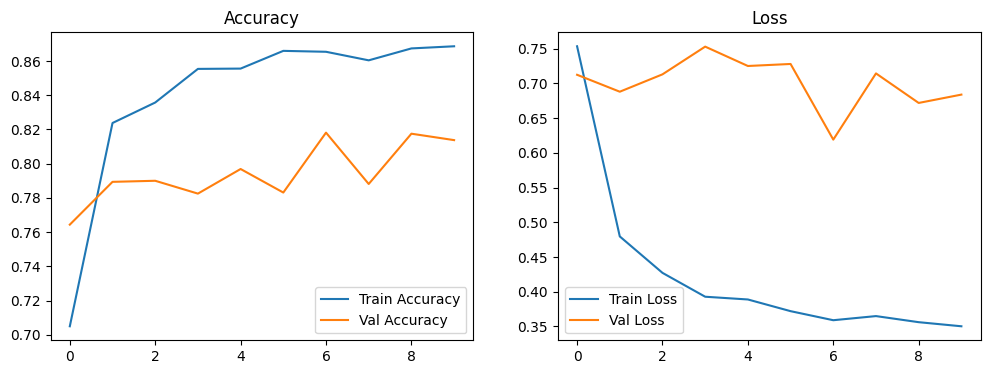

In [ ]:
# Trainig graph
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")

plt.show()

50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step


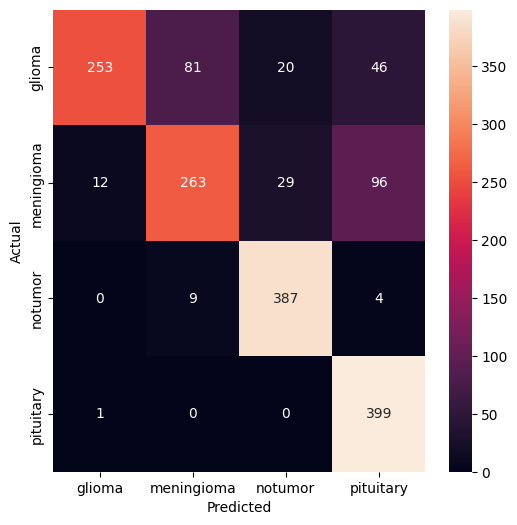

              precision    recall  f1-score   support

           0       0.95      0.63      0.76       400
           1       0.75      0.66      0.70       400
           2       0.89      0.97      0.93       400
           3       0.73      1.00      0.84       400

    accuracy                           0.81      1600
   macro avg       0.83      0.81      0.81      1600
weighted avg       0.83      0.81      0.81      1600



In [ ]:
# Confusion matrix and classification Report
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

pred = model.predict(test_generator)
y_pred = np.argmax(pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=train_generator.class_indices.keys(),
            yticklabels=train_generator.class_indices.keys())
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(test_generator.classes, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


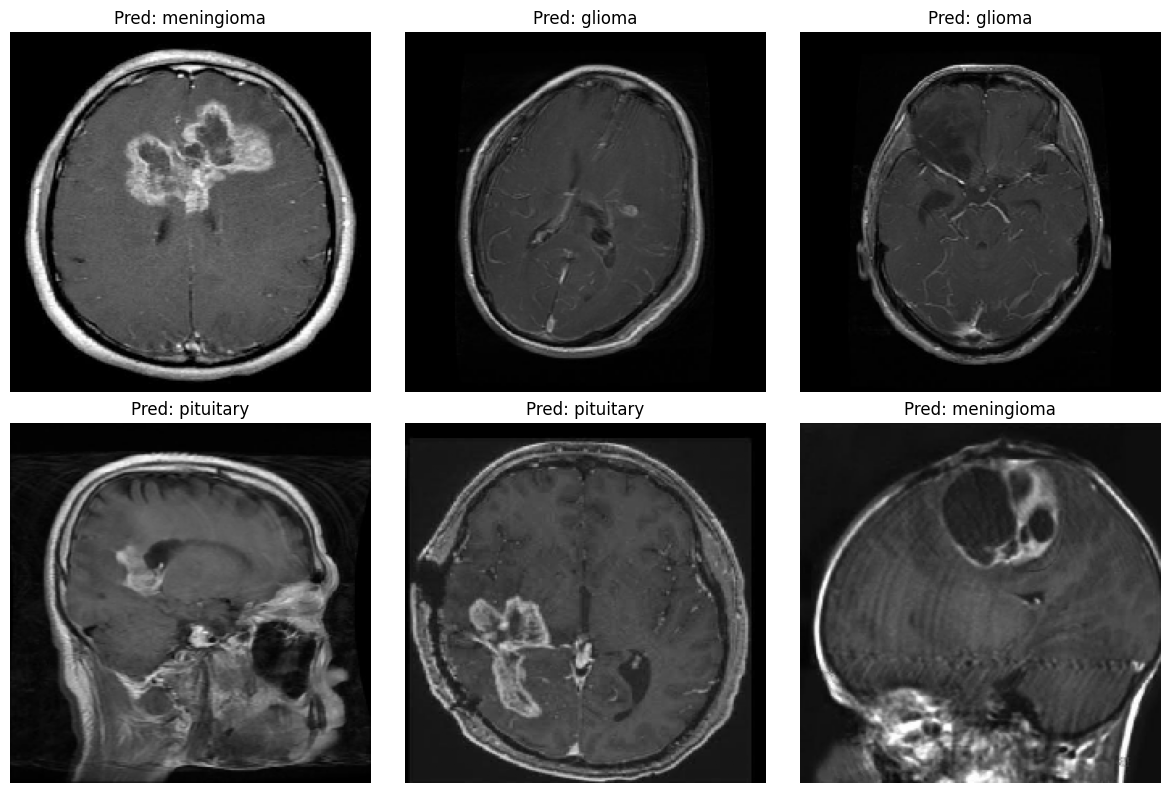

In [ ]:
# Visualizing sample prediction
class_names = list(train_generator.class_indices.keys())

images, labels = next(test_generator)

predictions = model.predict(images)
pred_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12,8))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(f"Pred: {class_names[pred_classes[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
class_names = list(train_generator.class_indices.keys())

In [ ]:
## Create Grad-CAM function
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_index = tf.argmax(predictions[0])
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

    return heatmap

In [ ]:
os.listdir()

['.config',
 'brain-tumor-mri-dataset.zip',
 'Testing',
 'kaggle.json',
 'Training',
 'sample_data']

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = test_generator.filepaths[0]

from tensorflow.keras.preprocessing import image
import numpy as np

# get image path
img_path = test_generator.filepaths[0]

# load image
img = image.load_img(img_path, target_size=(224,224))

# convert to array
img_array = image.img_to_array(img)

# normalize
img_array = img_array / 255.0

# add batch dimension
img_array = np.expand_dims(img_array, axis=0)

In [ ]:
#Get Prediction
pred = model.predict(img_array)
pred_class = np.argmax(pred)
confidence = np.max(pred)

class_names = list(train_generator.class_indices.keys())
predicted_label = class_names[pred_class]

if predicted_label == "notumor":
    tumor_status = "No Tumor Detected"
else:
    tumor_status = "Tumor Detected"


1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


In [ ]:
# Apply Grad-CAM
last_conv_layer_name = "Conv_1"

heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# convert PIL image to numpy
img_np = np.array(img)

# overlay heatmap
superimposed_img = heatmap * 0.4 + img_np
superimposed_img = np.uint8(superimposed_img)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


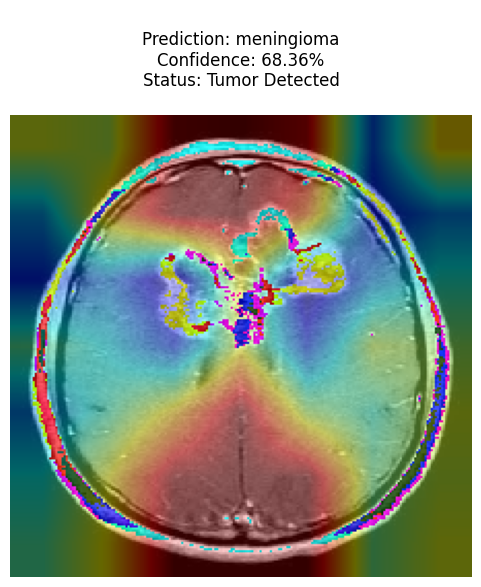

In [ ]:

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.imshow(superimposed_img)
plt.title(f"""
Prediction: {predicted_label}
Confidence: {confidence*100:.2f}%
Status: {tumor_status}
""")
plt.axis("off")
plt.show()

In [ ]:
# Measuring the Inference Time
import time

img_array = np.expand_dims(images[0], axis=0)

start = time.time()
model.predict(img_array)
end = time.time()

print("Inference Time (ms):", (end - start) * 1000)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Inference Time (ms): 116.61505699157715


In [ ]:
## installing lime
!pip install lime shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=4603ce846f60763b96d162bbeb59ae30036b3894340b43fb8e0f8eab700f582c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime import lime_image
from skimage.segmentation import mark_boundaries
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
## prediction functions for lime
def predict_fn(images):
    images = np.array(images)
    return model.predict(images)

In [ ]:
explainer = lime_image.LimeImageExplainer()

explanation = explainer.explain_instance(
    img_array[0],
    predict_fn,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 26s 26s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

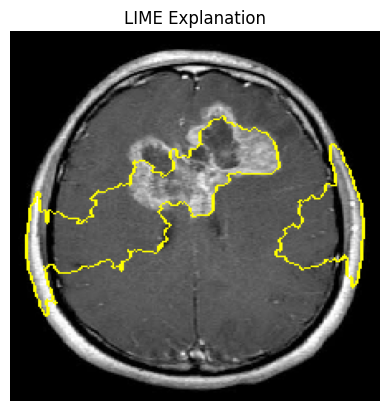

In [ ]:
## Visualizing the superpixel part through lime
lime_img, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=5,
    hide_rest=False
)

lime_result = mark_boundaries(lime_img, mask)

plt.imshow(lime_result)
plt.title("LIME Explanation")
plt.axis("off")

In [ ]:
## Applying SHAP
# installing SHAP

import shap

In [ ]:
# creating image Masker which tells SHAP how to hide parts of the image.
masker = shap.maskers.Image("inpaint_telea", (224,224,3))

In [ ]:
# SHAP explaner
explainer = shap.Explainer(model, masker)

In [ ]:
shap_values = explainer(img_array)

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:21, 21.89s/it]               


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


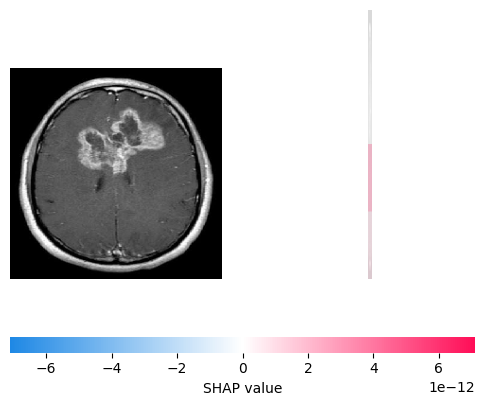

In [ ]:
## Visualixation of SHAP
# get prediction
pred = model.predict(img_array)
pred_class = np.argmax(pred)

# visualize shap
shap.image_plot(shap_values[0].values, img_array)

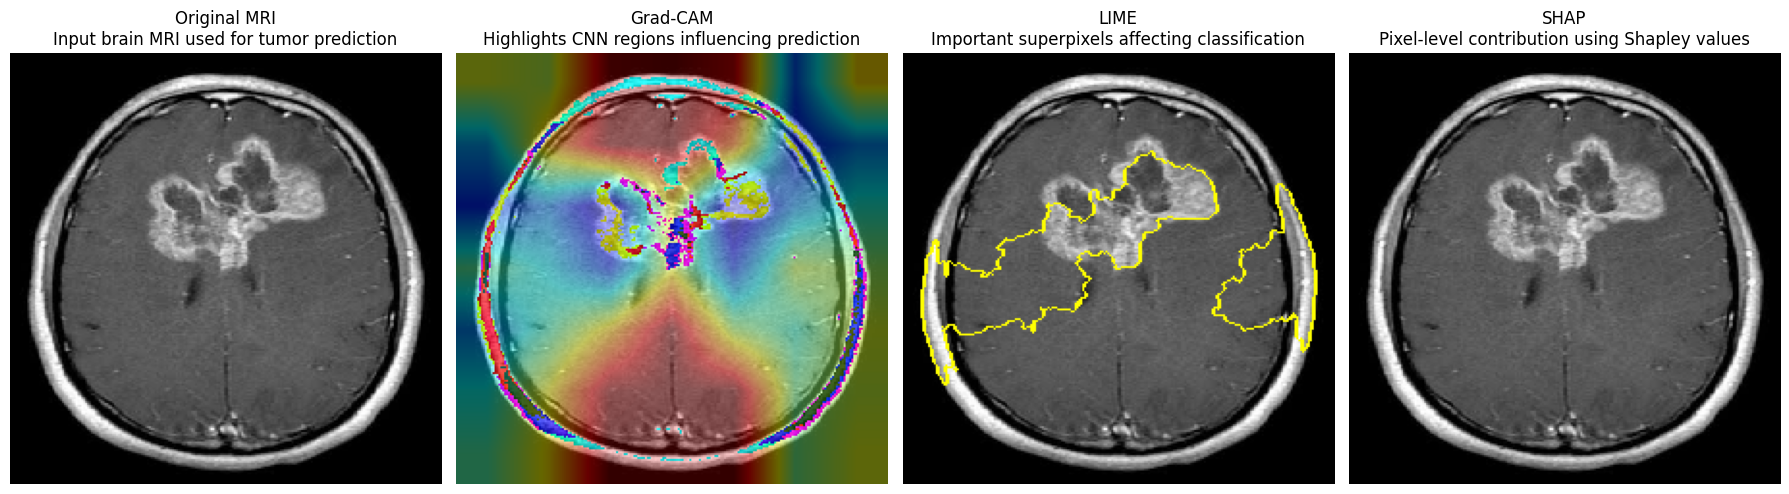

In [ ]:
plt.figure(figsize=(18,5))

# Original MRI
plt.subplot(1,4,1)
plt.imshow(img)
plt.title("Original MRI\nInput brain MRI used for tumor prediction")
plt.axis("off")

# Grad-CAM
plt.subplot(1,4,2)
plt.imshow(superimposed_img)
plt.title("Grad-CAM\nHighlights CNN regions influencing prediction")
plt.axis("off")

# LIME
plt.subplot(1,4,3)
plt.imshow(lime_result)
plt.title("LIME\nImportant superpixels affecting classification")
plt.axis("off")

# SHAP
plt.subplot(1,4,4)
plt.imshow(img)
plt.title("SHAP\nPixel-level contribution using Shapley values")
plt.axis("off")

plt.tight_layout()
plt.show()

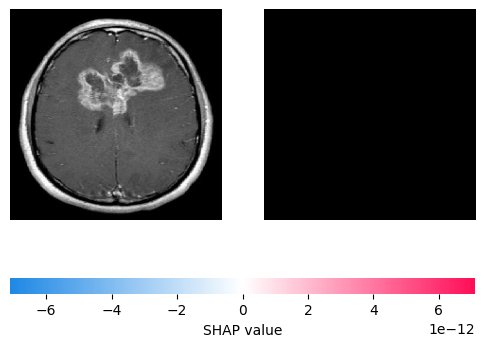

In [ ]:
shap.image_plot(shap_values.values, img_array)

In [ ]:
import pandas as pd

comparison = pd.DataFrame({
    "Method": ["Grad-CAM","LIME","SHAP"],
    "Explanation Level": ["Region","Superpixel","Pixel"],
    "Speed": ["Fast","Medium","Slow"],
    "Interpretability": ["Medium","High","Very High"]
})

comparison

,Method,Explanation Level,Speed,Interpretability
0,Grad-CAM,Region,Fast,Medium
1,LIME,Superpixel,Medium,High
2,SHAP,Pixel,Slow,Very High


In [ ]:
import pandas as pd
import numpy as np

# get predictions for entire test set
pred = model.predict(test_generator)
pred_classes = np.argmax(pred, axis=1)

class_names = list(train_generator.class_indices.keys())

# create dataframe
sample_df = pd.DataFrame({
    "Image": [path.split("/")[-1] for path in test_generator.filepaths[:15]],
    "Actual Class": [class_names[i] for i in test_generator.classes[:15]],
    "Predicted Class": [class_names[i] for i in pred_classes[:15]],
    "Confidence": np.max(pred[:15], axis=1)
})

sample_df

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step


,Image,Actual Class,Predicted Class,Confidence
0,Te-gl_1.jpg,glioma,meningioma,0.683645
1,Te-gl_10.jpg,glioma,glioma,0.977928
2,Te-gl_100.jpg,glioma,glioma,0.863377
3,Te-gl_101.jpg,glioma,pituitary,0.585024
4,Te-gl_102.jpg,glioma,pituitary,0.814457
5,Te-gl_103.jpg,glioma,meningioma,0.963094
6,Te-gl_104.jpg,glioma,meningioma,0.498187
7,Te-gl_105.jpg,glioma,glioma,0.995691
8,Te-gl_106.jpg,glioma,meningioma,0.711070
9,Te-gl_107.jpg,glioma,glioma,0.823731


In [5]:
import os
print(os.listdir())

['.config', 'sample_data']
